### Cell 1 — Imports

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

### Cell 2 — Data

In [3]:
torch.manual_seed(0)

X = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0],
                  [6.0], [7.0], [8.0], [9.0], [10.0]])
Y = X * 2

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: torch.Size([10, 1])
Y shape: torch.Size([10, 1])


### Cell 3 — Define the network using nn.Module

In [5]:
class SimpleNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 4)
        self.layer2 = nn.Linear(4, 1)
        self.activation = nn.LeakyReLU(0.01)

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.layer2(x)
        return x

model = SimpleNet()
print(model)

SimpleNet(
  (layer1): Linear(in_features=1, out_features=4, bias=True)
  (layer2): Linear(in_features=4, out_features=1, bias=True)
  (activation): LeakyReLU(negative_slope=0.01)
)


### Cell 4 — Check parameters

In [6]:
for name, param in model.named_parameters():
    print(f"{name:20s} | shape: {str(param.shape):15s} | values: {param.data}")

layer1.weight        | shape: torch.Size([4, 1]) | values: tensor([[-0.6623],
        [-0.4122],
        [ 0.0370],
        [ 0.3953]])
layer1.bias          | shape: torch.Size([4]) | values: tensor([ 0.6000, -0.6779, -0.4355,  0.3632])
layer2.weight        | shape: torch.Size([1, 4]) | values: tensor([[ 0.4152, -0.1029,  0.3742, -0.0806]])
layer2.bias          | shape: torch.Size([1]) | values: tensor([0.0529])


### Cell 5 — Define loss and optimizer

In [7]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

print("Loss function:", loss_fn)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


### Cell 6 — Test before training

In [8]:
with torch.no_grad():
    y_pred = model(X)

print("Predictions before training:")
for i in range(3):
    print(f"  Input: {X[i].item():.0f} | Predicted: {y_pred[i].item():.4f} | Target: {Y[i].item():.0f}")

Predictions before training:
  Input: 1 | Predicted: -0.0089 | Target: 2
  Input: 2 | Predicted: -0.0429 | Target: 4
  Input: 3 | Predicted: -0.0769 | Target: 6


### Cell 7 — Training loop

In [9]:
epochs = 3000
losses = []

for epoch in range(epochs):

    # Forward
    y_pred = model(X)

    # Loss
    loss = loss_fn(y_pred, Y)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

Epoch    0 | Loss: 158.724899
Epoch  500 | Loss: 0.051371
Epoch 1000 | Loss: 0.014881
Epoch 1500 | Loss: 0.004612
Epoch 2000 | Loss: 0.001726
Epoch 2500 | Loss: 0.000901


### Cell 8 — Test after training

In [10]:
with torch.no_grad():
    y_pred_final = model(X)

print("\nFinal predictions vs targets:")
for i in range(5):
    print(f"  Input: {X[i].item():.0f} | Predicted: {y_pred_final[i].item():.4f} | Target: {Y[i].item():.0f}")


Final predictions vs targets:
  Input: 1 | Predicted: 2.0780 | Target: 2
  Input: 2 | Predicted: 3.9879 | Target: 4
  Input: 3 | Predicted: 5.9900 | Target: 6
  Input: 4 | Predicted: 7.9921 | Target: 8
  Input: 5 | Predicted: 9.9941 | Target: 10


### Cell 9 — Plot the loss curve

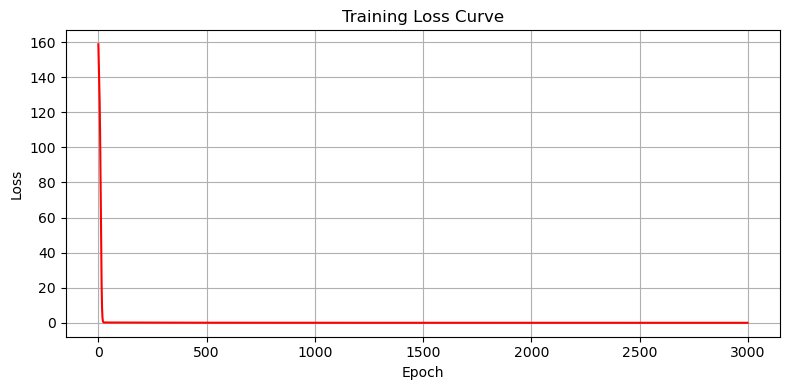

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color='red', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.tight_layout()
plt.savefig('03_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Cell 10 — Save the model

In [12]:
torch.save(model.state_dict(), '03_simplenet_weights.pth')
print("Model saved")

Model saved


### Cell 11 — Load it back and verify

In [13]:
loaded_model = SimpleNet()
loaded_model.load_state_dict(torch.load('03_simplenet_weights.pth'))
loaded_model.eval()

with torch.no_grad():
    test = loaded_model(torch.tensor([[7.0]]))
    print(f"Loaded model prediction for input 7: {test.item():.4f} (target: 14)")

Loaded model prediction for input 7: 13.9983 (target: 14)


# 03 — Neural Network with nn.Module

## What this notebook covers
Rebuilding the same 2-layer network from notebook 02 using PyTorch's
nn.Module — the proper structure used in all real projects.

---

## What changed from notebook 02

| Manual (02) | nn.Module (03) |
|-------------|----------------|
| `W1 = torch.randn(1, 4)` | `nn.Linear(1, 4)` |
| Bias initialized manually | Included automatically |
| `X @ W1 + b1` | Handled inside `forward()` |
| 12 lines to update weights | `optimizer.step()` |
| `W1.grad.zero_()` x4 | `optimizer.zero_grad()` |

Same math. nn.Module handles the bookkeeping.

---

## Key concepts

### nn.Module
- Base class for all PyTorch models
- Define layers in `__init__`
- Define data flow in `forward()`
- Parameters tracked automatically

### nn.Linear
- Implements `z = x @ W + b`
- Weights initialized automatically
- `nn.Linear(1, 4)` → 1 input, 4 outputs

### Loss function
- `nn.MSELoss()` — Mean Squared Error
- Same as `((y_pred - y_true) ** 2).mean()`

### Optimizer
- `torch.optim.SGD` — Stochastic Gradient Descent
- Replaces manual weight updates
- `optimizer.zero_grad()` — clears gradients
- `optimizer.step()` — updates all parameters

### Training loop (3 lines)
```python
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

### Loss curve
- Sharp drop early → model learns main pattern fast
- Long tail → fine-tuning small errors
- Flat line at zero → converged

### Model saving and loading
- `torch.save(model.state_dict(), 'file.pth')` — saves weights
- `model.load_state_dict(torch.load('file.pth'))` — restores weights
- Essential for long training runs

---

## Results
- Final loss: < 0.001
- Predictions accurate to 2 decimal places
- Model saved and reloaded successfully

---

## Connection to biomedical AI
Every real model I will build follows this exact structure:
```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        # define layers

    def forward(self, x):
        # define data flow
        return x
```

Chest X-ray classifier (DenseNet-121) and
ECG arrhythmia detector are both nn.Module subclasses.

---

